# 🌺 Classical Computer Vision Pipeline
## Lotus Flower Analysis using OpenCV

A Classical CV Pipeline processes images step by step:
Acquisition → Preprocessing → Enhancement → Segmentation → Feature Extraction → Decision

Real world use case: Automated flower quality inspection in agriculture!

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')
print()
print('📌 Pipeline Steps:')
print('   Step 1 → Image Acquisition & Display')
print('   Step 2 → Grayscale Conversion')
print('   Step 3 → Noise Removal (Gaussian Blur)')
print('   Step 4 → Edge Detection (Canny)')
print('   Step 5 → Thresholding & Segmentation')
print('   Step 6 → Morphological Operations')
print('   Step 7 → Contour Detection')
print('   Step 8 → Feature Extraction & Decision')

✅ Libraries imported successfully!

📌 Pipeline Steps:
   Step 1 → Image Acquisition & Display
   Step 2 → Grayscale Conversion
   Step 3 → Noise Removal (Gaussian Blur)
   Step 4 → Edge Detection (Canny)
   Step 5 → Thresholding & Segmentation
   Step 6 → Morphological Operations
   Step 7 → Contour Detection
   Step 8 → Feature Extraction & Decision


##  Image Acquisition

We load the lotus image and display it in original color.
Image shape tells us: Height x Width x Channels (3 = RGB)

✅ Image loaded successfully!
   Image shape  : (3024, 4032, 3)
   Height       : 3024 pixels
   Width        : 4032 pixels
   Channels     : 3 (R, G, B)


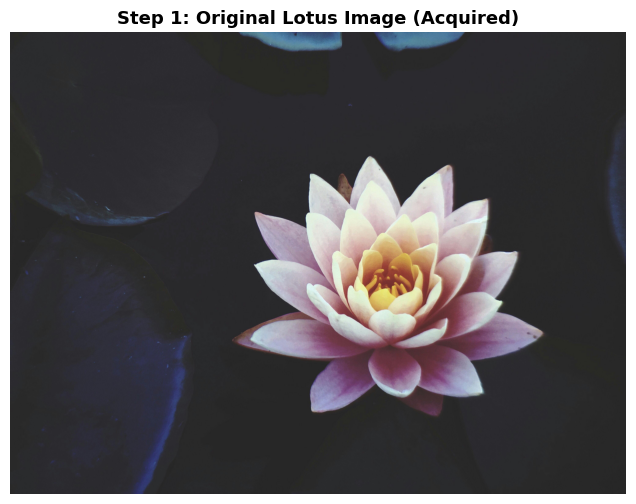

In [2]:
# Load image
img_bgr = cv2.imread('/content/lotus_image.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f'✅ Image loaded successfully!')
print(f'   Image shape  : {img_rgb.shape}')
print(f'   Height       : {img_rgb.shape[0]} pixels')
print(f'   Width        : {img_rgb.shape[1]} pixels')
print(f'   Channels     : {img_rgb.shape[2]} (R, G, B)')

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Step 1: Original Lotus Image (Acquired)',
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

##  Grayscale Conversion
Color images have 3 channels (R, G, B) → too much data!
Grayscale has only 1 channel → brightness only
Most CV algorithms work on grayscale → simpler & faster
Formula: Gray = 0.299R + 0.587G + 0.114B

✅ Grayscale conversion done!
   Original shape : (3024, 4032, 3)  (3 channels)
   Grayscale shape: (3024, 4032)  (1 channel)
   Pixel range    : 15 to 255


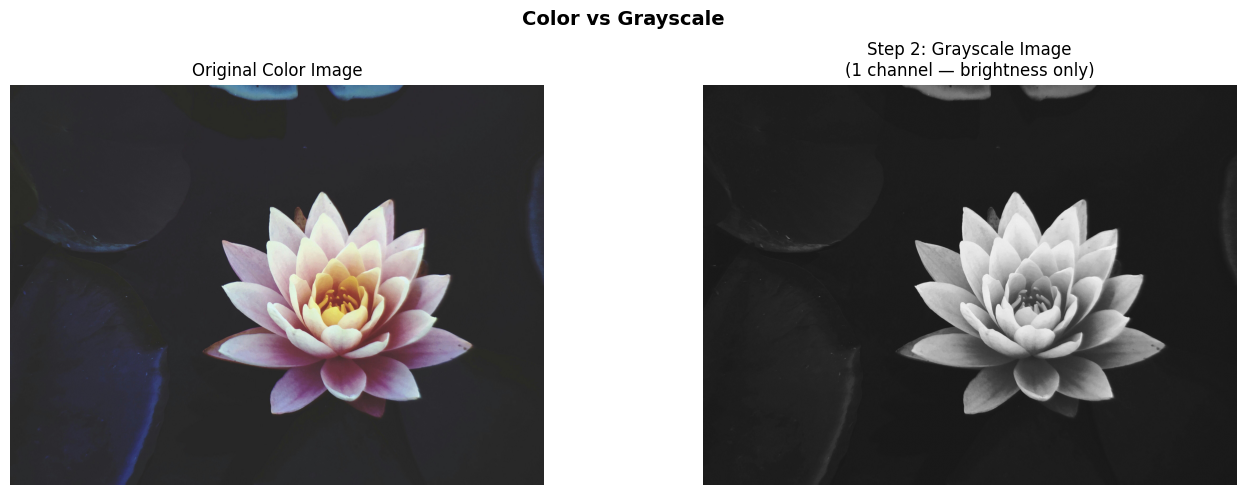

In [3]:
# Convert to grayscale
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f'✅ Grayscale conversion done!')
print(f'   Original shape : {img_rgb.shape}  (3 channels)')
print(f'   Grayscale shape: {gray.shape}  (1 channel)')
print(f'   Pixel range    : {gray.min()} to {gray.max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Color Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Step 2: Grayscale Image\n(1 channel — brightness only)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Color vs Grayscale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Noise Removal (Gaussian Blur)
Real images have noise (random pixel variations).
Gaussian Blur smoothens the image before edge detection.
Without blur → too many false edges detected!
Kernel size (15,15) → larger = more smoothing

✅ Gaussian Blur applied!
   Kernel size : 15x15
   Effect      : Smoothens noise before edge detection


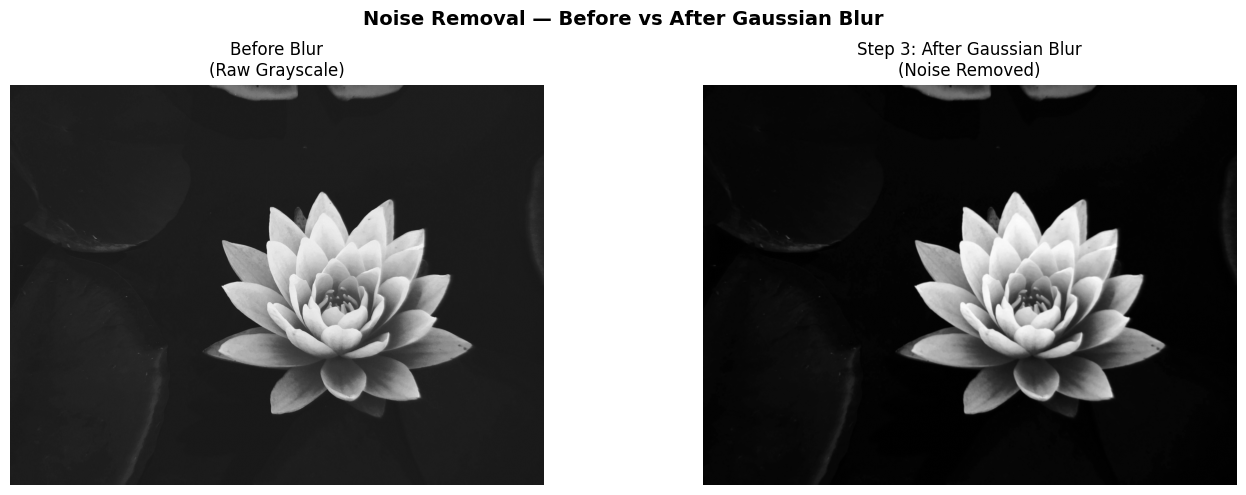

In [4]:
# Apply Gaussian Blur to remove noise
blurred = cv2.GaussianBlur(gray, (15, 15), 0)

print('✅ Gaussian Blur applied!')
print(f'   Kernel size : 15x15')
print(f'   Effect      : Smoothens noise before edge detection')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Before Blur\n(Raw Grayscale)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(blurred, cmap='gray')
axes[1].set_title('Step 3: After Gaussian Blur\n(Noise Removed)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Noise Removal — Before vs After Gaussian Blur',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Edge Detection (Canny)
Edges = boundaries where brightness changes sharply.
Canny is the most popular edge detector in Computer Vision.
threshold1=30 → minimum edge strength
threshold2=100 → maximum edge strength
Pixels between thresholds → kept only if connected to strong edge

✅ Canny Edge Detection applied!
   Lower threshold : 30
   Upper threshold : 100
   Edge pixels     : 18703


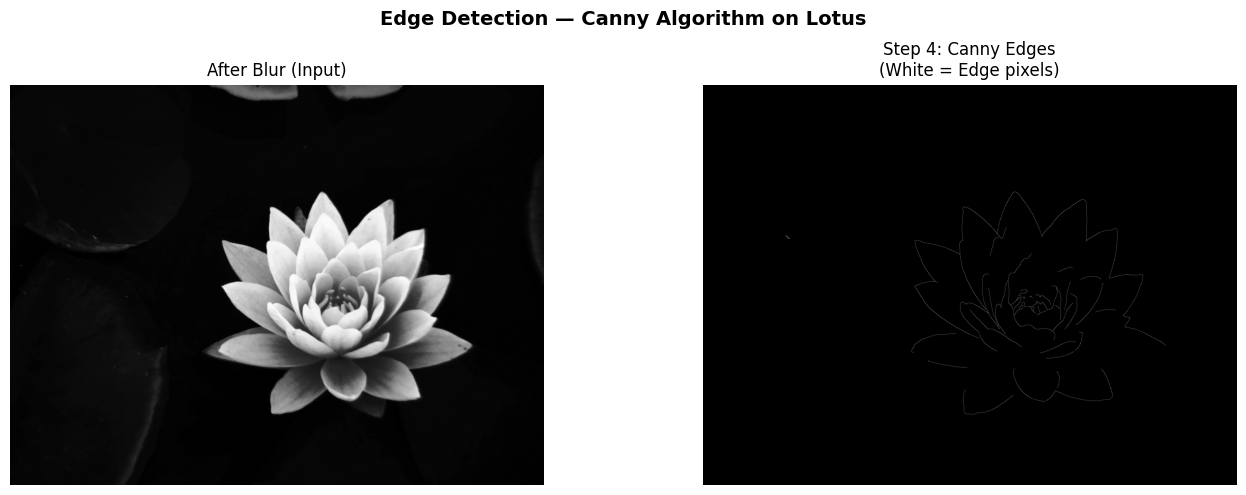

In [5]:
# Apply Canny Edge Detection
edges = cv2.Canny(blurred, threshold1=30, threshold2=100)

print('✅ Canny Edge Detection applied!')
print(f'   Lower threshold : 30')
print(f'   Upper threshold : 100')
print(f'   Edge pixels     : {np.sum(edges > 0)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(blurred, cmap='gray')
axes[0].set_title('After Blur (Input)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Step 4: Canny Edges\n(White = Edge pixels)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Edge Detection — Canny Algorithm on Lotus',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Thresholding & Segmentation
Thresholding separates the flower from the dark background.
Pixels brighter than threshold → White (flower)
Pixels darker than threshold → Black (background)
OTSU method → automatically finds best threshold value!

✅ OTSU Thresholding applied!
   Auto threshold value : 115
   White pixels (flower): 1551058
   Black pixels (bg)    : 10641710
   Flower area          : 12.7% of image


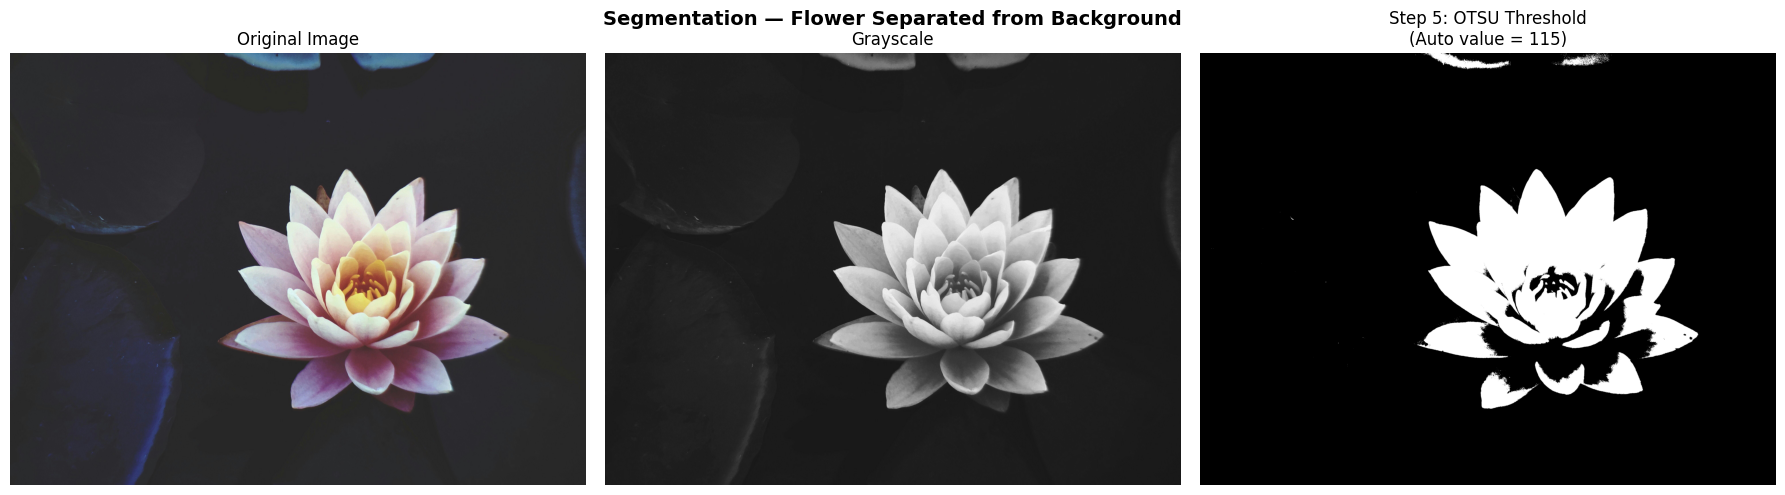

In [6]:
# Apply OTSU Thresholding
thresh_val, thresh = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print('✅ OTSU Thresholding applied!')
print(f'   Auto threshold value : {thresh_val:.0f}')
print(f'   White pixels (flower): {np.sum(thresh == 255)}')
print(f'   Black pixels (bg)    : {np.sum(thresh == 0)}')
flower_pct = np.sum(thresh == 255) / thresh.size * 100
print(f'   Flower area          : {flower_pct:.1f}% of image')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale', fontsize=12)
axes[1].axis('off')

axes[2].imshow(thresh, cmap='gray')
axes[2].set_title(f'Step 5: OTSU Threshold\n(Auto value = {thresh_val:.0f})',
                   fontsize=12)
axes[2].axis('off')

plt.suptitle('Segmentation — Flower Separated from Background',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Morphological Operations
After thresholding, the mask has small holes and noise.
Morphological operations clean this up:
- Dilation → expands white regions (fills gaps)
- Erosion → shrinks white regions (removes noise)
- Opening = Erosion + Dilation → removes small noise
- Closing = Dilation + Erosion → fills small holes

✅ Morphological Operations applied!
   Kernel size : 5x5
   Opening     : Removes small noise pixels
   Closing     : Fills small holes in flower


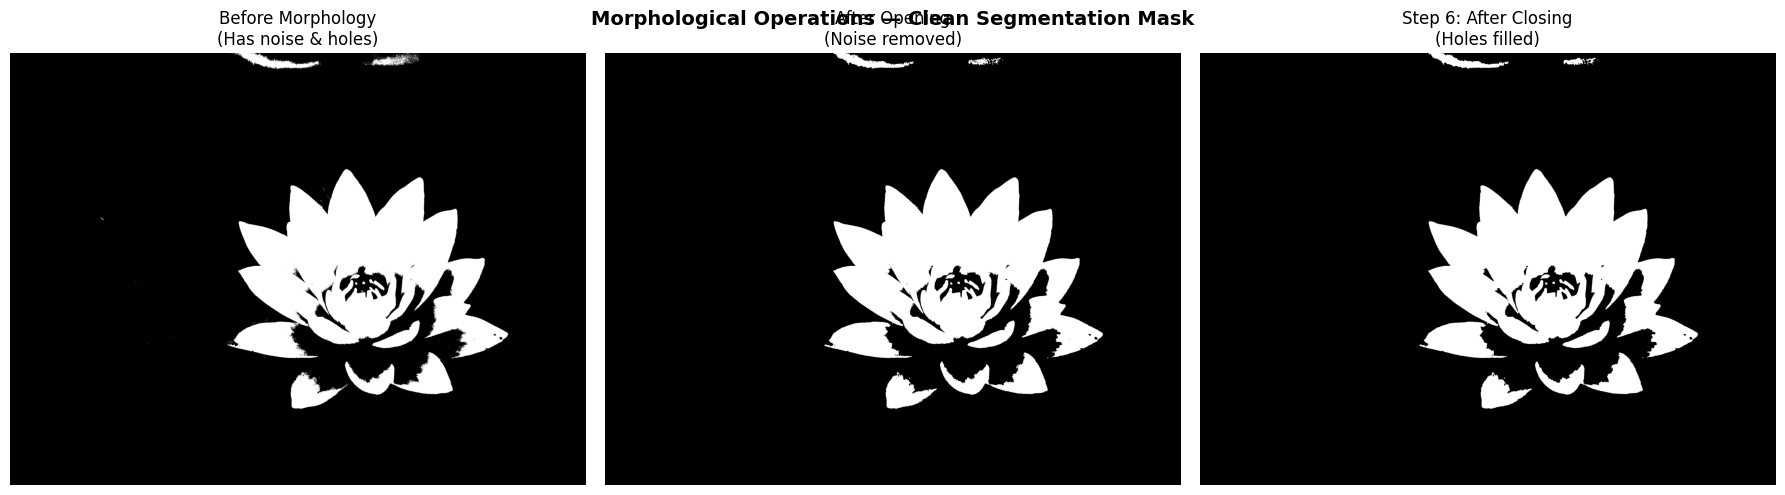

In [7]:
# Create kernel for morphological operations
kernel = np.ones((5, 5), np.uint8)

# Opening → remove small noise
opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Closing → fill small holes inside flower
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

print('✅ Morphological Operations applied!')
print(f'   Kernel size : 5x5')
print(f'   Opening     : Removes small noise pixels')
print(f'   Closing     : Fills small holes in flower')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(thresh, cmap='gray')
axes[0].set_title('Before Morphology\n(Has noise & holes)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(opened, cmap='gray')
axes[1].set_title('After Opening\n(Noise removed)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(closed, cmap='gray')
axes[2].set_title('Step 6: After Closing\n(Holes filled)', fontsize=12)
axes[2].axis('off')

plt.suptitle('Morphological Operations — Clean Segmentation Mask',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Contour Detection
Contours are the boundaries/outlines of objects in image.
Find contours on the cleaned mask from previous step.
Each contour = one region/object detected
Largest contour = the lotus flower itself!

✅ Contours detected!
   Total contours found : 14
   Largest contour area : 1317727 pixels


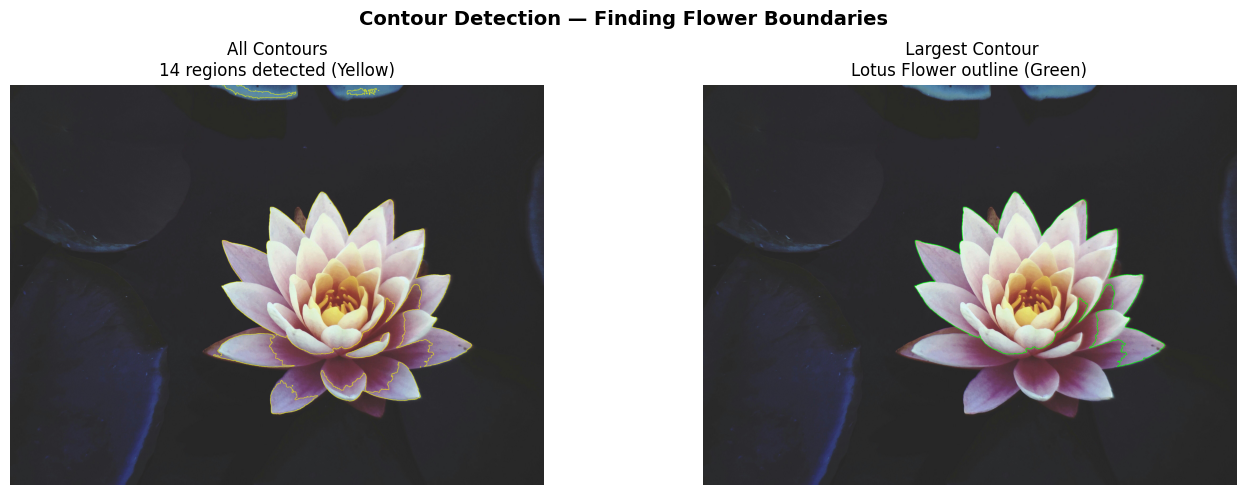

In [9]:
# Find contours on cleaned mask
contours, _ = cv2.findContours(
    closed,
    cv2.RETR_EXTERNAL,    # only outer contours
    cv2.CHAIN_APPROX_SIMPLE
)

# Sort contours by area (largest first)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Draw all contours on original image
img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (255, 255, 0), 2)

# Draw only largest contour (the flower)
img_flower = img_rgb.copy()
cv2.drawContours(img_flower, [contours[0]], -1, (0, 255, 0), 3)

print('✅ Contours detected!')
print(f'   Total contours found : {len(contours)}')
print(f'   Largest contour area : {cv2.contourArea(contours[0]):.0f} pixels')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_contours)
axes[0].set_title(f'All Contours\n{len(contours)} regions detected (Yellow)',
                   fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_flower)
axes[1].set_title(' Largest Contour\nLotus Flower outline (Green)',
                   fontsize=12)
axes[1].axis('off')

plt.suptitle('Contour Detection — Finding Flower Boundaries',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Extraction
Extract meaningful measurements from the detected flower.
These features describe the flower mathematically:
- Area → total size of flower in pixels
- Perimeter → length of flower boundary
- Circularity → how round/circular the flower is (1.0 = perfect circle)
- Bounding box → smallest rectangle around flower

     FLOWER FEATURE EXTRACTION
  Area         : 1317727 pixels²
  Perimeter    : 9769 pixels
  Circularity  : 0.1735 (1.0=circle)
  Bounding Box : 1888x1318 pixels
  Aspect Ratio : 1.43


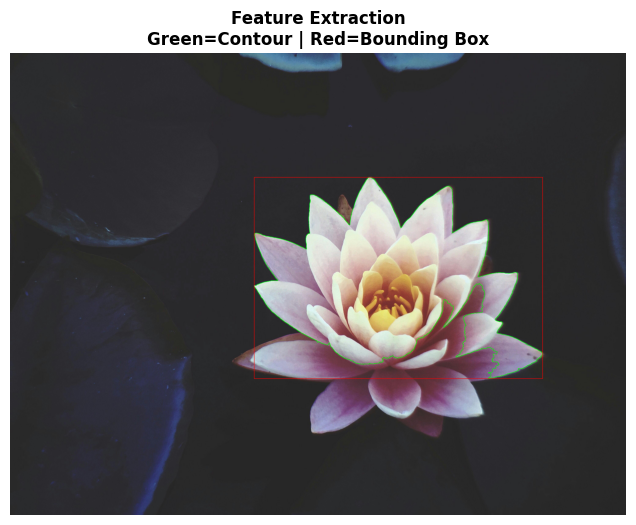

In [13]:
# Extract features from largest contour (the flower)
flower_contour = contours[0]

# Area
area = cv2.contourArea(flower_contour)

# Perimeter
perimeter = cv2.arcLength(flower_contour, True)

# Circularity → 4π × Area / Perimeter²
circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

# Bounding box
x, y, w, h = cv2.boundingRect(flower_contour)

# Aspect ratio
aspect_ratio = w / h

# Draw bounding box on image
img_features = img_rgb.copy()
cv2.drawContours(img_features, [flower_contour], -1, (0, 255, 0), 2)
cv2.rectangle(img_features, (x, y), (x+w, y+h), (255, 0, 0), 2)

print('=' * 45)
print('     FLOWER FEATURE EXTRACTION')
print('=' * 45)
print(f'  Area         : {area:.0f} pixels²')
print(f'  Perimeter    : {perimeter:.0f} pixels')
print(f'  Circularity  : {circularity:.4f} (1.0=circle)')
print(f'  Bounding Box : {w}x{h} pixels')
print(f'  Aspect Ratio : {aspect_ratio:.2f}')
print('=' * 45)

plt.figure(figsize=(8, 6))
plt.imshow(img_features)
plt.title(f'Feature Extraction\nGreen=Contour | Red=Bounding Box',
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

## Full Pipeline Visualization
Display all steps of the pipeline in one single figure.


/tmp/ipykernel_1683/2953010465.py:37: UserWarning: Glyph 127802 (\N{HIBISCUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127802 (\N{HIBISCUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


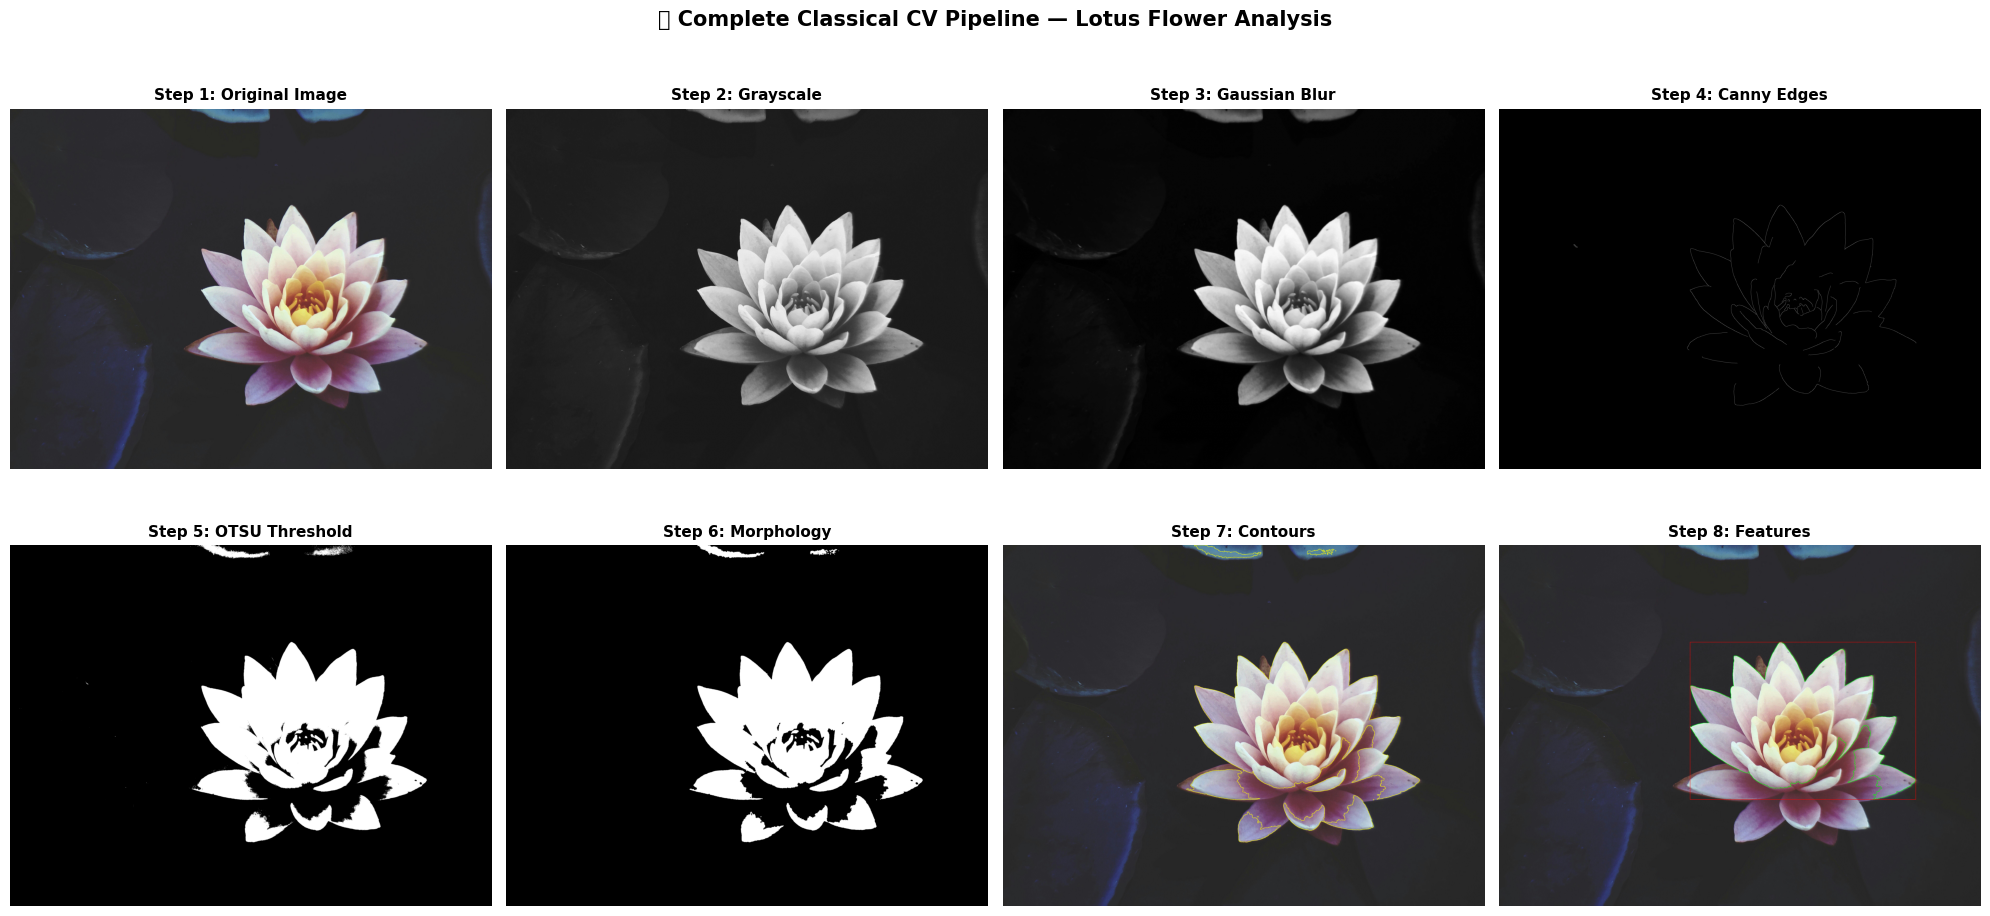

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes[0,0].imshow(img_rgb)
axes[0,0].set_title('Step 1: Original Image', fontsize=11, fontweight='bold')
axes[0,0].axis('off')

axes[0,1].imshow(gray, cmap='gray')
axes[0,1].set_title('Step 2: Grayscale', fontsize=11, fontweight='bold')
axes[0,1].axis('off')

axes[0,2].imshow(blurred, cmap='gray')
axes[0,2].set_title('Step 3: Gaussian Blur', fontsize=11, fontweight='bold')
axes[0,2].axis('off')

axes[0,3].imshow(edges, cmap='gray')
axes[0,3].set_title('Step 4: Canny Edges', fontsize=11, fontweight='bold')
axes[0,3].axis('off')

axes[1,0].imshow(thresh, cmap='gray')
axes[1,0].set_title('Step 5: OTSU Threshold', fontsize=11, fontweight='bold')
axes[1,0].axis('off')

axes[1,1].imshow(closed, cmap='gray')
axes[1,1].set_title('Step 6: Morphology', fontsize=11, fontweight='bold')
axes[1,1].axis('off')

axes[1,2].imshow(img_contours)
axes[1,2].set_title('Step 7: Contours', fontsize=11, fontweight='bold')
axes[1,2].axis('off')

axes[1,3].imshow(img_features)
axes[1,3].set_title('Step 8: Features', fontsize=11, fontweight='bold')
axes[1,3].axis('off')

plt.suptitle('🌺 Complete Classical CV Pipeline — Lotus Flower Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##  Decision & Final Summary
Based on extracted features, make a final decision.
Is the lotus flower healthy and complete?
Circularity score tells us how perfectly round the flower is.
Area coverage tells us how much of the image is flower.

In [16]:
# Decision Logic
total_pixels   = img_rgb.shape[0] * img_rgb.shape[1]
area_coverage  = (area / total_pixels) * 100

print('=' * 55)
print('    🌺 LOTUS FLOWER ANALYSIS — FINAL REPORT')
print('=' * 55)
print()
print('📊 EXTRACTED FEATURES:')
print(f'   Area           : {area:.0f} pixels²')
print(f'   Perimeter      : {perimeter:.0f} pixels')
print(f'   Circularity    : {circularity:.4f}')
print(f'   Aspect Ratio   : {aspect_ratio:.2f}')
print(f'   Area Coverage  : {area_coverage:.1f}% of image')
print(f'   Bounding Box   : {w} x {h} pixels')
print()
print('🔍 DECISION:')

if circularity > 0.3:
    print('   Flower Shape   : ✅ Good circular shape detected')
else:
    print('   Flower Shape   : ⚠️  Irregular shape detected')

if area_coverage > 5:
    print('   Flower Size    : ✅ Good size — clearly visible')
else:
    print('   Flower Size    : ⚠️  Small — may be partially visible')

if aspect_ratio > 0.7 and aspect_ratio < 1.3:
    print('   Aspect Ratio   : ✅ Balanced — flower is symmetric')
else:
    print('   Aspect Ratio   : ⚠️  Asymmetric flower detected')

print()
print('📌 PIPELINE SUMMARY:')
print(f'   Step 1 → Image Acquisition    ✅')
print(f'   Step 2 → Grayscale Conversion ✅')
print(f'   Step 3 → Gaussian Blur        ✅')
print(f'   Step 4 → Canny Edge Detection ✅')
print(f'   Step 5 → OTSU Thresholding    ✅')
print(f'   Step 6 → Morphological Ops    ✅')
print(f'   Step 7 → Contour Detection    ✅')
print(f'   Step 8 → Feature Extraction   ✅')
print()
print('=' * 55)

    🌺 LOTUS FLOWER ANALYSIS — FINAL REPORT

📊 EXTRACTED FEATURES:
   Area           : 1317727 pixels²
   Perimeter      : 9769 pixels
   Circularity    : 0.1735
   Aspect Ratio   : 1.43
   Area Coverage  : 10.8% of image
   Bounding Box   : 1888 x 1318 pixels

🔍 DECISION:
   Flower Shape   : ⚠️  Irregular shape detected
   Flower Size    : ✅ Good size — clearly visible
   Aspect Ratio   : ⚠️  Asymmetric flower detected

📌 PIPELINE SUMMARY:
   Step 1 → Image Acquisition    ✅
   Step 2 → Grayscale Conversion ✅
   Step 3 → Gaussian Blur        ✅
   Step 4 → Canny Edge Detection ✅
   Step 5 → OTSU Thresholding    ✅
   Step 6 → Morphological Ops    ✅
   Step 7 → Contour Detection    ✅
   Step 8 → Feature Extraction   ✅

